In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (889, 14)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully.
Shape: (889, 14)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  


In [6]:
features = [
    "sex",
    "embarked",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

X = df[features]
y = df["survived"]

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Feature shape: (889, 7)
Target distribution:
survived
0    549
1    340
Name: count, dtype: int64
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 711
Testing samples: 178

Training distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [8]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (889, 14)


In [9]:
features = [
    "sex",
    "embarked",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

X = df[features]
y = df["survived"]

print("Feature shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Feature shape: (889, 7)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 711
Testing samples: 178

Training distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [12]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [13]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

decision_tree_predictions = decision_tree_pipeline.predict(X_test)
decision_tree_probabilities = (
    decision_tree_pipeline.predict_proba(X_test)[:, 1]
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

random_forest_predictions = random_forest_pipeline.predict(X_test)
random_forest_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [15]:
print("Logistic predictions:", len(logistic_predictions))
print("Decision Tree predictions:", len(decision_tree_predictions))
print("Random Forest predictions:", len(random_forest_predictions))
print("Actual test labels:", len(y_test))

Logistic predictions: 178
Decision Tree predictions: 178
Random Forest predictions: 178
Actual test labels: 178


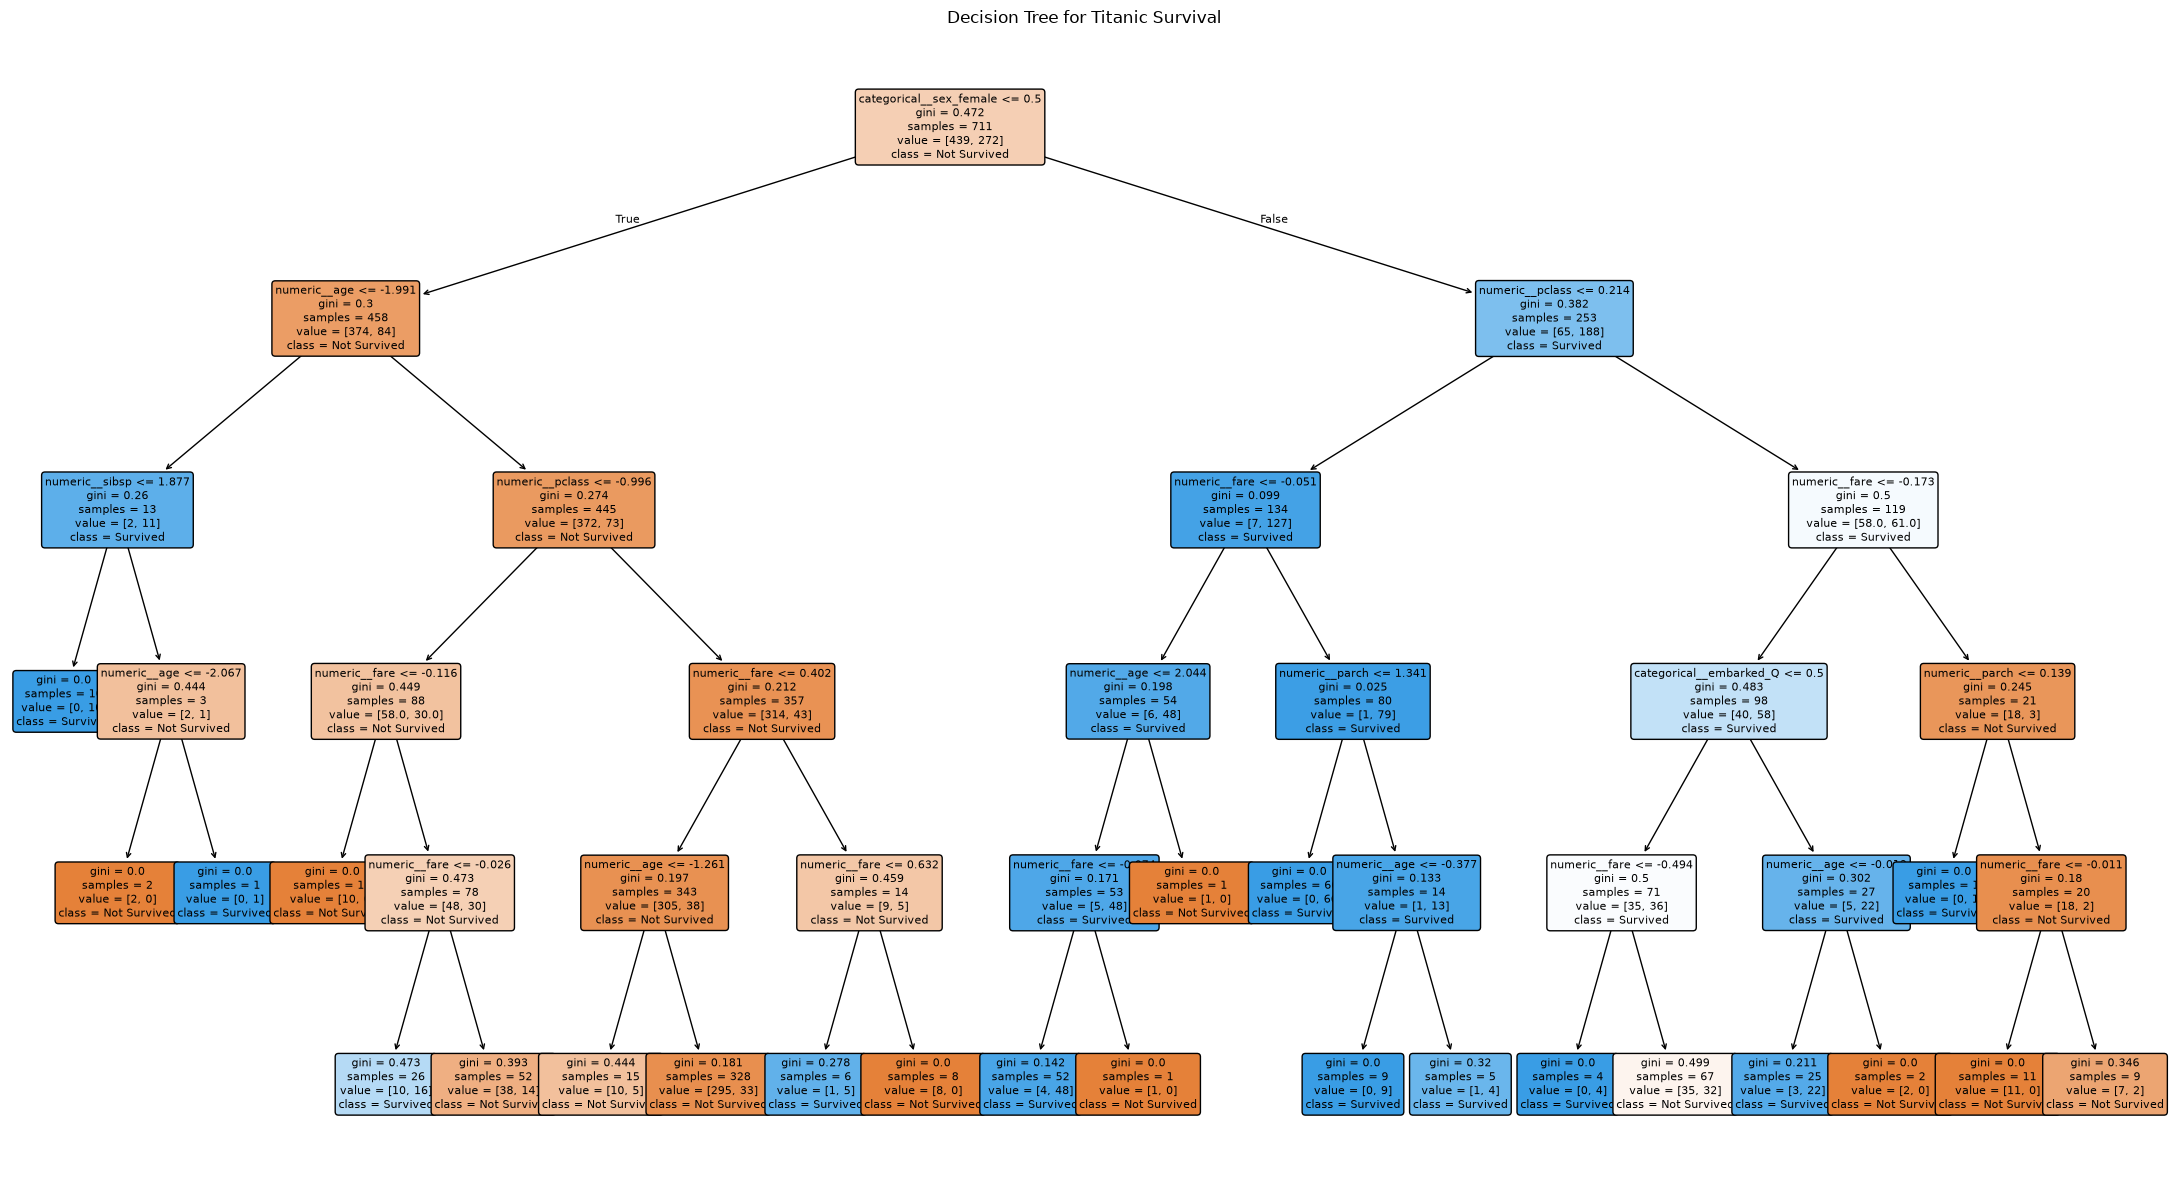

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
tree_model = decision_tree_pipeline.named_steps["model"]

feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival")
plt.tight_layout()
plt.show()

In [17]:
tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
tree_model = decision_tree_pipeline.named_steps["model"]
feature_names = tree_preprocessor.get_feature_names_out()

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ---------------------------------------------------------
# Evaluation function
# ---------------------------------------------------------

def evaluate_model(name, y_true, predictions, probabilities):
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    auc = roc_auc_score(y_true, probabilities)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }


# ---------------------------------------------------------
# Evaluate all three classifiers
# ---------------------------------------------------------

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions,
        decision_tree_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions,
        random_forest_probabilities
    )
)


# ---------------------------------------------------------
# Comparison table
# ---------------------------------------------------------

comparison_df = pd.DataFrame(results)

print("Model Comparison")
print(comparison_df.round(4))

Model Comparison
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8090     0.7833  0.6912  0.7344  0.8610
1        Decision Tree    0.7640     0.7600  0.5588  0.6441  0.8374
2        Random Forest    0.8202     0.7812  0.7353  0.7576  0.8179


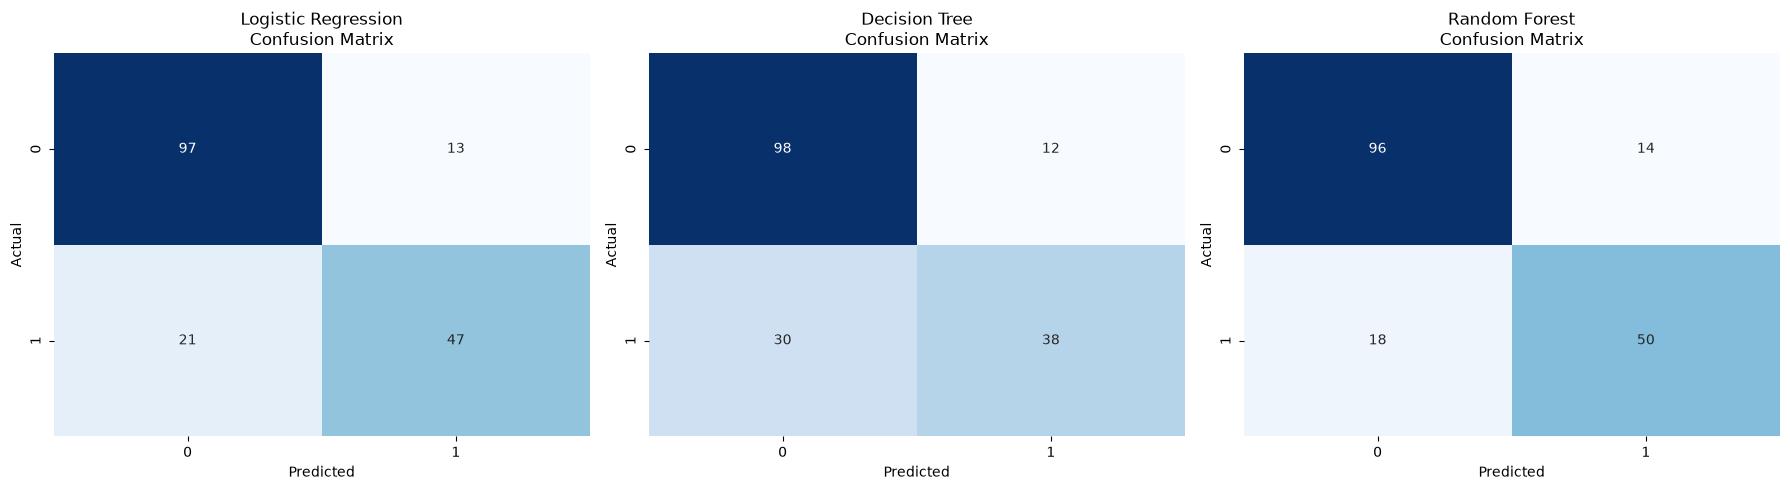

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, predictions) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

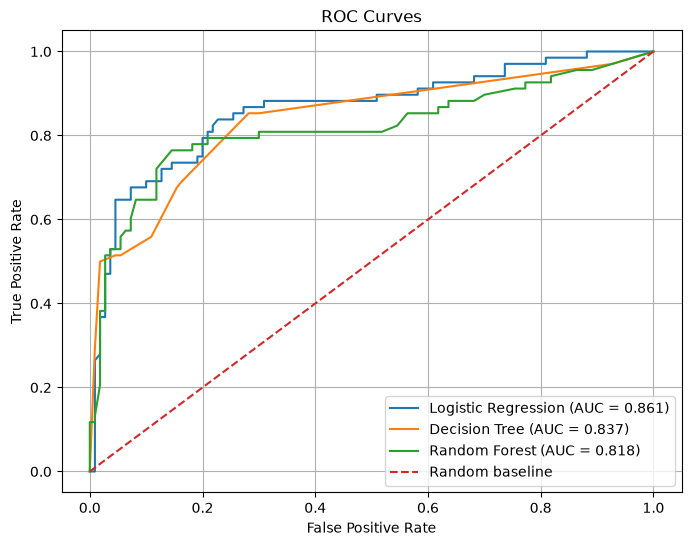

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": decision_tree_probabilities,
    "Random Forest": random_forest_probabilities
}

for name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
comparison_df.to_csv(
    "outputs/classification_comparison.csv",
    index=False
)

print("Classification comparison saved.")

Classification comparison saved.


In [22]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ---------------------------------------------------------
# Show original class balance
# ---------------------------------------------------------

print("Original class balance:")
print(y.value_counts())

print("\nOriginal class proportions:")
print(y.value_counts(normalize=True))


# ---------------------------------------------------------
# 1. Baseline Logistic Regression
# ---------------------------------------------------------

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)


# ---------------------------------------------------------
# 2. Logistic Regression with class_weight="balanced"
# ---------------------------------------------------------

balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)


# ---------------------------------------------------------
# 3. Logistic Regression + SMOTE
# ---------------------------------------------------------

smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

smote_pipeline.fit(X_train, y_train)

smote_pred = smote_pipeline.predict(X_test)


# ---------------------------------------------------------
# Compare Precision / Recall / F1
# ---------------------------------------------------------

imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(
            y_test, baseline_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, baseline_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, baseline_pred, zero_division=0
        )
    },
    {
        "Strategy": "class_weight='balanced'",
        "Precision": precision_score(
            y_test, balanced_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, balanced_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, balanced_pred, zero_division=0
        )
    },
    {
        "Strategy": "SMOTE",
        "Precision": precision_score(
            y_test, smote_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, smote_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, smote_pred, zero_division=0
        )
    }
])

print("\nImbalance Handling Comparison:")
print(imbalance_results.round(4))

Original class balance:
survived
0    549
1    340
Name: count, dtype: int64

Original class proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Imbalance Handling Comparison:
                  Strategy  Precision  Recall      F1
0                 Baseline     0.7833  0.6912  0.7344
1  class_weight='balanced'     0.7183  0.7500  0.7338
2                    SMOTE     0.7353  0.7353  0.7353


### Imbalance Handling Interpretation

The baseline model achieved a precision of 0.7833, recall of 0.6912, and F1 score of 0.7344. Using `class_weight='balanced'` increased recall to 0.7500, although precision decreased to 0.7183 and the F1 score remained similar at 0.7338. SMOTE produced balanced precision and recall of 0.7353 each, with an F1 score of 0.7353. Overall, the three approaches show different trade-offs between precision and recall, with SMOTE providing the most balanced precision-recall result in this comparison.

In [23]:
imbalance_results.to_csv(
    "outputs/imbalance_comparison.csv",
    index=False
)

print("Saved: outputs/imbalance_comparison.csv")

Saved: outputs/imbalance_comparison.csv


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipeline_for_tuning = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                oob_score=True,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 score:")
print(grid_search.best_score_)

best_rf_pipeline = grid_search.best_estimator_

print("\nOOB score:")
print(best_rf_pipeline.named_steps["model"].oob_score_)

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best CV F1 score:
0.7408312771917277

OOB score:
0.8213783403656821


### Random Forest Hyperparameter Tuning Interpretation

GridSearchCV evaluated different combinations of `n_estimators`, `max_depth`, and `max_features` using 5-fold cross-validation with F1 score as the scoring metric. The best parameter combination was `n_estimators=200`, `max_depth=5`, and `max_features='sqrt'`, with a cross-validation F1 score of approximately 0.7408. The resulting Random Forest achieved an out-of-bag (OOB) score of approximately 0.8214. The OOB score provides an additional estimate of model performance using samples not included in each bootstrap training sample.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features used to predict fare
regression_features = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]

print("Regression feature shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

Regression feature shape: (889, 7)
Target shape: (889,)


In [26]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training samples:", len(X_reg_train))
print("Regression testing samples:", len(X_reg_test))

Regression training samples: 711
Regression testing samples: 178


### Stratified Train/Test Split Interpretation

Stratification was used so that the proportion of survived and not-survived passengers is maintained approximately equally in both the training and test sets. This is important because the target classes are not perfectly balanced in the Titanic dataset. Maintaining a similar class distribution helps make the model evaluation more representative of the original cleaned dataset.

In [27]:
numeric_reg_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_reg_features = [
    "sex",
    "embarked"
]

numeric_reg_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_reg_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_reg_pipeline,
            numeric_reg_features
        ),
        (
            "categorical",
            categorical_reg_pipeline,
            categorical_reg_features
        )
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

print("Regression pipeline created successfully.")

Regression pipeline created successfully.


In [28]:
regression_pipeline.fit(X_reg_train, y_reg_train)

fare_predictions = regression_pipeline.predict(X_reg_test)

print("Regression model trained successfully.")

Regression model trained successfully.


In [ ]:
from sklearn.metrics import r2_score

# Get predictions from the fitted regression pipeline
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Calculate R²
r2 = r2_score(y_reg_test, y_reg_pred)

# Calculate transformed predictor count
X_reg_test_transformed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

n = len(y_reg_test)
p = X_reg_test_transformed.shape[1]

# Calculate Adjusted R²
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("R²:", r2)
print("Number of transformed predictors:", p)   
print("Adjusted R²:", adjusted_r2)

R²: 0.3481625721605428
Number of transformed predictors: 10
Adjusted R²: 0.3091303908527908


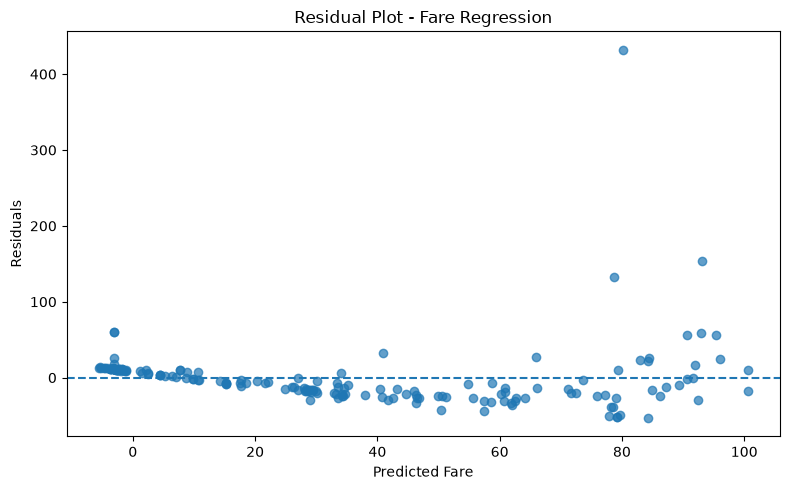

In [ ]:
residuals = y_reg_test - fare_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    fare_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Regression")
plt.tight_layout()
plt.show()

In [ ]:
# Final classification comparison
final_classification = comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

final_classification = final_classification.round(4)

print("FINAL CLASSIFIER COMPARISON")
print(final_classification.to_string(index=False))

FINAL CLASSIFIER COMPARISON
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.8090     0.7833  0.6912 0.7344 0.8610
      Decision Tree    0.7640     0.7600  0.5588 0.6441 0.8374
      Random Forest    0.8202     0.7812  0.7353 0.7576 0.8179


In [ ]:
final_regression = pd.DataFrame([
    {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2
    }
]).round(4)

print("\nFINAL REGRESSION METRICS")
print(final_regression.to_string(index=False))


FINAL REGRESSION METRICS
    MAE    RMSE     R2  Adjusted_R2
21.0986 41.7021 0.3482       0.3213


In [ ]:
final_classification.to_csv(
    "outputs/final_classification_comparison.csv",
    index=False
)

final_regression.to_csv(
    "outputs/final_regression_metrics.csv",
    index=False
)

print("Final metric tables saved.")

Final metric tables saved.


In [ ]:
final_classification = comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

final_classification = final_classification.round(4)

print("FINAL CLASSIFIER COMPARISON")
print(final_classification.to_string(index=False))

FINAL CLASSIFIER COMPARISON
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.8090     0.7833  0.6912 0.7344 0.8610
      Decision Tree    0.7640     0.7600  0.5588 0.6441 0.8374
      Random Forest    0.8202     0.7812  0.7353 0.7576 0.8179


In [ ]:
best_rf_pipeline = grid_search.best_estimator_

In [ ]:
import joblib
from pathlib import Path

model_path = Path("models/best_rf_pipeline.joblib")

joblib.dump(best_rf_pipeline, model_path)

print(f"Saved complete pipeline to: {model_path}")

Saved complete pipeline to: models\best_rf_pipeline.joblib


In [ ]:
loaded_pipeline = joblib.load("models/best_rf_pipeline.joblib")

print("Pipeline reloaded successfully.")
print(loaded_pipeline)

Pipeline reloaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                    

In [ ]:
raw_sample = pd.DataFrame({
    "sex": ["female"],
    "embarked": ["S"],
    "pclass": [1],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [80.0]
})

prediction = loaded_pipeline.predict(raw_sample)
probability = loaded_pipeline.predict_proba(raw_sample)[:, 1]

print("Prediction:", prediction[0])
print("Survival probability:", probability[0])

Prediction: 1
Survival probability: 0.9676254561433741


In [ ]:
p = X_reg_test.shape[1]

In [ ]:
# Number of predictors after preprocessing/one-hot encoding
X_reg_test_transformed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

n = len(y_reg_test)
p = X_reg_test_transformed.shape[1]

adjusted_r2_corrected = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("Number of transformed predictors:", p)
print("Corrected Adjusted R²:", adjusted_r2_corrected)

Number of transformed predictors: 10
Corrected Adjusted R²: 0.3091303908527908


In [ ]:
final_regression = pd.DataFrame([
    {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2_corrected
    }
]).round(4)

print(final_regression)

       MAE     RMSE      R2  Adjusted_R2
0  21.0986  41.7021  0.3482       0.3091


In [ ]:
final_regression = pd.DataFrame([
    {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2_corrected
    }
]).round(4)

print("FINAL REGRESSION METRICS")
print(final_regression.to_string(index=False))

FINAL REGRESSION METRICS
    MAE    RMSE     R2  Adjusted_R2
21.0986 41.7021 0.3482       0.3091


In [ ]:
final_regression.to_csv(
    "outputs/final_regression_metrics.csv",
    index=False
)

print("Updated regression metrics saved.")

Updated regression metrics saved.


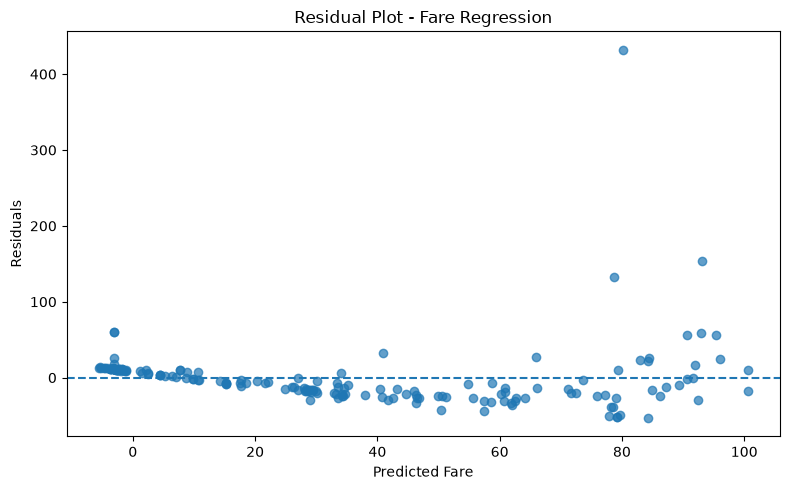

In [ ]:
residuals = y_reg_test - fare_predictions

plt.figure(figsize=(8, 5))
plt.scatter(fare_predictions, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Regression")
plt.tight_layout()
plt.show()

### Residual Plot and Heteroscedasticity Interpretation

The residual plot shows that the residuals are not spread with completely constant variance across the predicted fare values. The spread becomes wider for higher predicted fare values, indicating a pattern consistent with heteroscedasticity. This suggests that the linear regression model does not maintain constant residual variance across the full range of predictions.

In [ ]:
# Final combined model comparison table

final_classification = comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

final_classification = final_classification.round(4)

final_regression = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2_corrected
    }
]).round(4)

final_model_comparison = pd.concat(
    [
        final_classification.assign(Model_Type="Classification"),
        final_regression.assign(Model_Type="Regression")
    ],
    ignore_index=True,
    sort=False
)

final_model_comparison = final_model_comparison[
    [
        "Model_Type",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "MAE",
        "RMSE",
        "R2",
        "Adjusted_R2"
    ]
]

print(final_model_comparison.to_string(index=False))

final_model_comparison.to_csv(
    "outputs/final_model_comparison.csv",
    index=False
)

print("\nSaved: outputs/final_model_comparison.csv")

    Model_Type               Model  Accuracy  Precision  Recall     F1    AUC     MAE    RMSE     R2  Adjusted_R2
Classification Logistic Regression    0.8090     0.7833  0.6912 0.7344 0.8610     NaN     NaN    NaN          NaN
Classification       Decision Tree    0.7640     0.7600  0.5588 0.6441 0.8374     NaN     NaN    NaN          NaN
Classification       Random Forest    0.8202     0.7812  0.7353 0.7576 0.8179     NaN     NaN    NaN          NaN
    Regression   Linear Regression       NaN        NaN     NaN    NaN    NaN 21.0986 41.7021 0.3482       0.3091

Saved: outputs/final_model_comparison.csv


### Final Classifier Recommendation

The three classifiers show different performance across the evaluation metrics. The Random Forest achieved an accuracy of 0.8202, recall of 0.7353, and F1 score of 0.7576, while Logistic Regression achieved an AUC of 0.8610 with an accuracy of 0.8090. The Decision Tree produced lower recall and F1 values than the other two models in this evaluation. Based on these observed metrics, the Random Forest provides the strongest overall combination of accuracy, recall, and F1 score in this comparison.

### Modeling Preprocessing Strategy

Numeric features (`pclass`, `age`, `sibsp`, `parch`, and `fare`) are
median-imputed and standardized using `StandardScaler`.

Categorical features (`sex` and `embarked`) are imputed using the
most-frequent value and one-hot encoded using
`OneHotEncoder(handle_unknown="ignore")`.

All preprocessing steps are contained inside the modeling pipelines
and are fitted only on the training data. The test data is only
transformed during evaluation, preventing test-set information from
leaking into training.